# JWST phase-diversity phase retrieval

A focused image alone cannot reliably distinguish several wavefront symmetries. We
add a known defocus diversity and recover one shared, pixel-scale OPD represented by
an implicit separable Fourier basis. The implicit representation evaluates the OPD
directly and avoids materialising a dense stack of basis images.

In [1]:
import equinox as eqx
import jax.numpy as np
import jax.random as jr
import matplotlib as mpl
import matplotlib.pyplot as plt
import optax
from matplotlib.colors import CenteredNorm, PowerNorm
from tqdm.notebook import tqdm

import dLux as dl
import dLux.utils as dlu

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.family": "serif", "image.origin": "lower"})
cmaps = {"intensity": mpl.colormaps["inferno"], "opd": mpl.colormaps["RdBu"], "residual": mpl.colormaps["seismic"]}

## Construct focused and diverse JWST models

Both systems share the same pupil object. The diverse branch adds a known 150 nm RMS
defocus before the common focal propagation. The sampled JWST geometry is explicitly
described as representative rather than a flight pupil model.

In [2]:
pupil_grid = dl.GridSpec(n=(128, 128), diam=8.0, unit="m")
focal_grid = dl.GridSpec(n=56, d=25, unit="mas")
transmission = dl.JWSTLike(oversample=3).build(pupil_grid)
support = transmission > 0.5

shape = dl.FourierBasis(128, 12).shape
coeffs = 12e-9 * jr.normal(jr.key(0), shape)
opd = dl.FourierBasis(128, 12, coeffs)
pupil = dl.Optic(transmission=transmission, opd=opd, normalise=True)

coords = pupil_grid.coordinates
defocus = dlu.zernike(4, coords, 6.5)
defocus = 150e-9 * defocus / dlu.rms_norm(defocus, support)
diversity = dl.Optic(opd=defocus)
focus = dl.Fraunhofer(focal_grid)

focused = dl.OpticalSystem(grid=pupil_grid, layers=[("pupil", pupil), ("focus", focus)])
diverse = dl.OpticalSystem(grid=pupil_grid, layers=[("pupil", pupil), ("diversity", diversity), ("focus", focus)])
source = dl.Source(wavelengths=1.8, flux=5.2, units={"wavelengths": "um", "flux": "log"})

## Simulate the phase-diversity pair

In [3]:
focus_image = dl.Image(focused.model(source), read_noise=5.0)
diverse_image = dl.Image(diverse.model(source), read_noise=5.0)
focus_data = focus_image.simulate(jr.key(1), n_frames=32)
diverse_data = diverse_image.simulate(jr.key(2), n_frames=32)

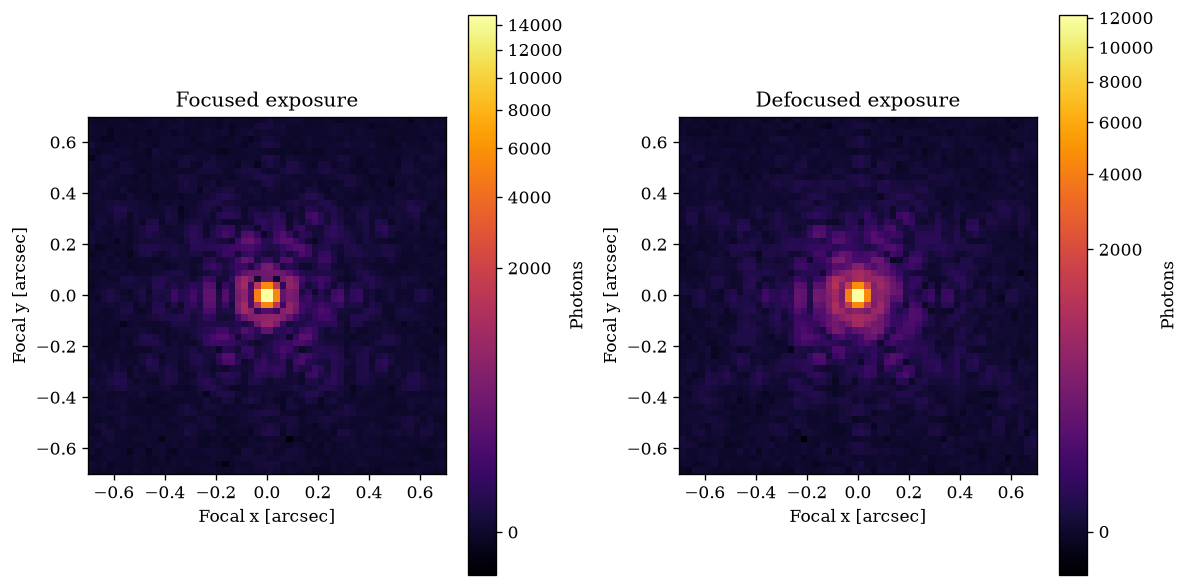

In [4]:
## COLLAPSE: Plotting code
extent = focal_grid.extent(ndim=2, unit="arcsec")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, image, title in zip(axes, [focus_data, diverse_data], ["Focused exposure", "Defocused exposure"]):
    im = ax.imshow(image.data, cmaps["intensity"], extent=extent, norm=PowerNorm(0.3))
    ax.set(title=title, xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
    fig.colorbar(im, ax=ax, label="Photons")
fig.tight_layout()
plt.show()

## Recover the shared implicit OPD

Only the Fourier coeffs are differentiated. Each objective evaluation inserts
the same coeffs into both optical branches and averages their squared
per-pixel z-scores.

In [5]:
params = np.zeros_like(coeffs)


def predict(params, focused, diverse, source):
    focused = focused.set("pupil.opd.coeffs", params)
    diverse = diverse.set("pupil.opd.coeffs", params)
    return focused.model(source), diverse.model(source)


@eqx.filter_jit
@eqx.filter_value_and_grad
def loss_fn(params, focused, diverse, source, focus_data, diverse_data):
    focus_model, diverse_model = predict(params, focused, diverse, source)
    focus_loss = np.mean(focus_data.z_score(focus_model) ** 2)
    diverse_loss = np.mean(diverse_data.z_score(diverse_model) ** 2)
    return (focus_loss + diverse_loss) / 2


initial_focus, initial_diverse = predict(params, focused, diverse, source)
optim = optax.sgd(5e-18, momentum=0.7)
state = optim.init(params)
losses = []
for _ in tqdm(range(60)):
    loss, grads = loss_fn(params, focused, diverse, source, focus_data, diverse_data)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    losses.append(loss)
fit_focus, fit_diverse = predict(params, focused, diverse, source)

  0%|          | 0/60 [00:00<?, ?it/s]

## Diagnose image and pupil recovery

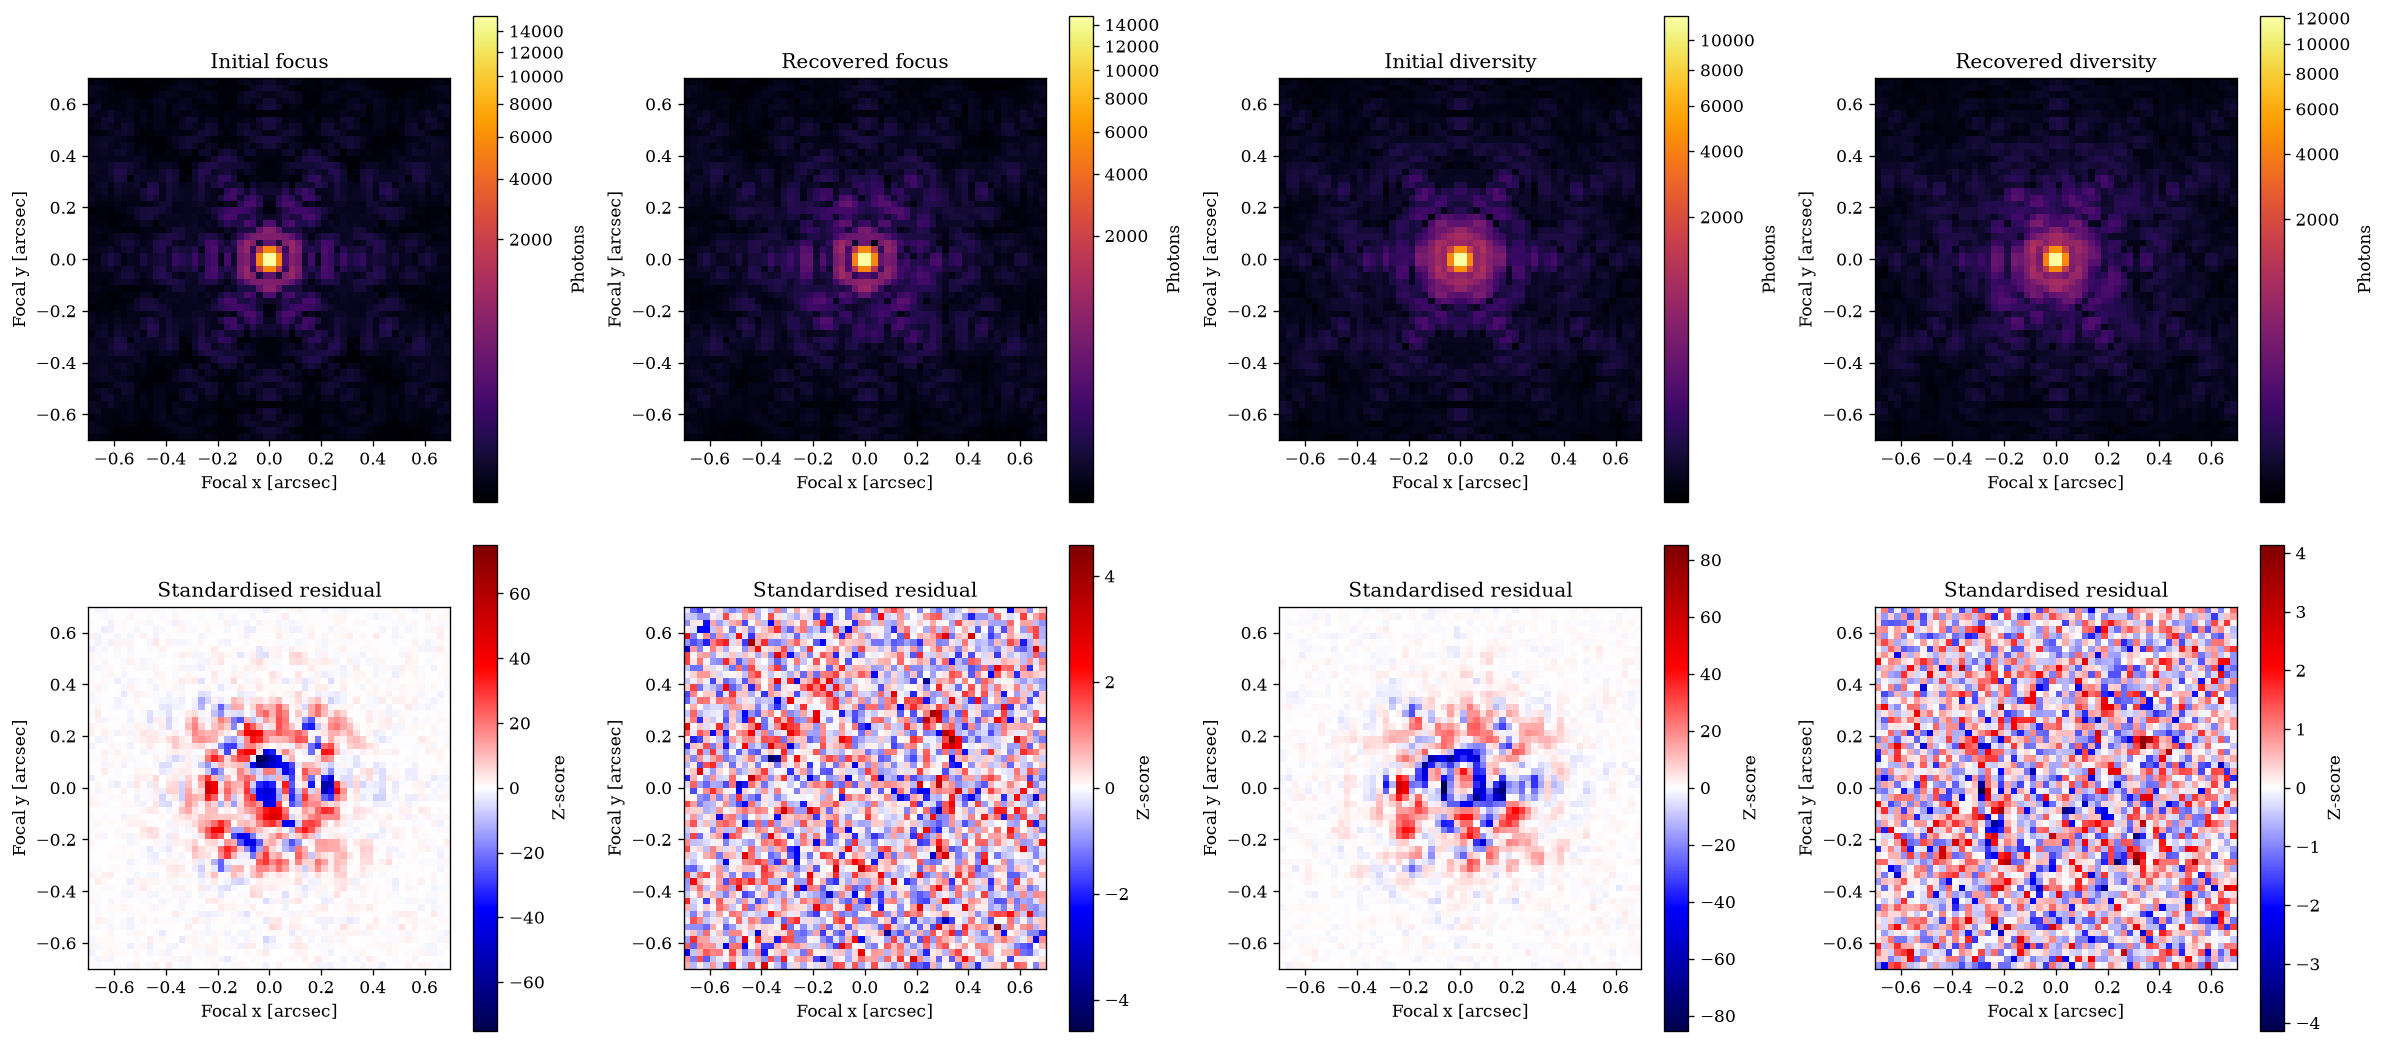

In [6]:
## COLLAPSE: Plotting code
models = [initial_focus, fit_focus, initial_diverse, fit_diverse]
data = [focus_data, focus_data, diverse_data, diverse_data]
titles = ["Initial focus", "Recovered focus", "Initial diversity", "Recovered diversity"]
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for i, (model, exposure, title) in enumerate(zip(models, data, titles)):
    im = axes[0, i].imshow(model.data, cmaps["intensity"], extent=extent, norm=PowerNorm(0.3))
    axes[0, i].set(title=title, xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
    fig.colorbar(im, ax=axes[0, i], label="Photons")
    im = axes[1, i].imshow(exposure.z_score(model), cmaps["residual"], extent=extent, norm=CenteredNorm())
    axes[1, i].set(title="Standardised residual", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
    fig.colorbar(im, ax=axes[1, i], label="Z-score")
fig.tight_layout()
plt.show()

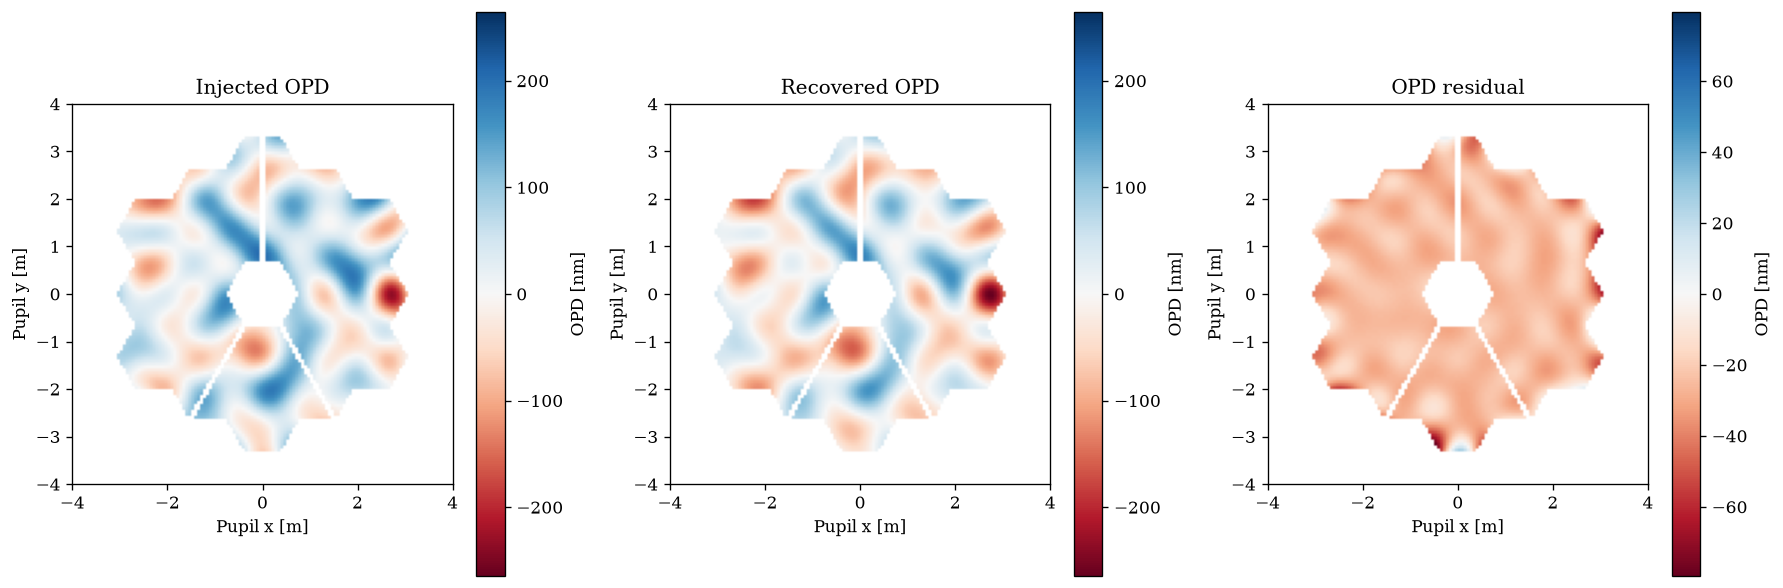

In [7]:
## COLLAPSE: Plotting code
truth_opd = np.where(support, 1e9 * opd.evaluate(), np.nan)
fit_opd = np.where(support, 1e9 * dl.FourierBasis(128, 12, params).evaluate(), np.nan)
residual = fit_opd - truth_opd
extent_pupil = pupil_grid.extent(ndim=2, unit="m")
limit = np.nanmax(np.abs(np.stack([truth_opd, fit_opd])))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, image, title, norm in zip(
    axes,
    [truth_opd, fit_opd, residual],
    ["Injected OPD", "Recovered OPD", "OPD residual"],
    [CenteredNorm(halfrange=limit), CenteredNorm(halfrange=limit), CenteredNorm()],
):
    im = ax.imshow(image, cmaps["opd"], extent=extent_pupil, norm=norm)
    ax.set(title=title, xlabel="Pupil x [m]", ylabel="Pupil y [m]")
    fig.colorbar(im, ax=ax, label="OPD [nm]")
fig.tight_layout()
plt.show()

The diversity image breaks ambiguities that remain in the focused intensity while
the implicit Fourier basis keeps a high-dimensional OPD compact. Hessian and Fisher
calculations are intentionally omitted because materialising curvature for every
Fourier coefficient is not appropriate for this documentation-scale problem.